In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [3]:
X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.60,
    random_state=42
)

df_kmeans = pd.DataFrame(
    X,
    columns=['Feature_1','Feature_2']
)

print("Original K-Means Dataset:")
df_kmeans.head()

Original K-Means Dataset:


,Feature_1,Feature_2
0,-7.155244,-7.390016
1,-7.395875,-7.110843
2,-2.015671,8.281780
3,4.509270,2.632436
4,-8.102502,-7.484961


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Wi

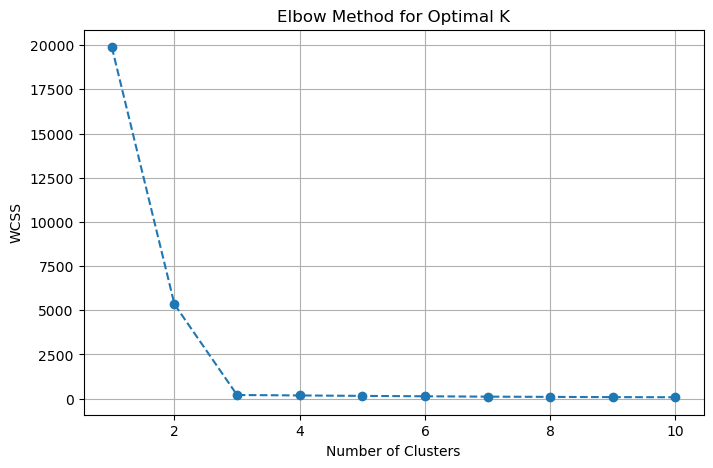

In [5]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=42
    )
    
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)


plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o',
    linestyle='--'
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [7]:
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)


clusters = kmeans.fit_predict(X)


df_kmeans['Cluster'] = clusters


df_kmeans.head()

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,Feature_1,Feature_2,Cluster
0,-7.155244,-7.390016,1
1,-7.395875,-7.110843,1
2,-2.015671,8.281780,0
3,4.509270,2.632436,2
4,-8.102502,-7.484961,1


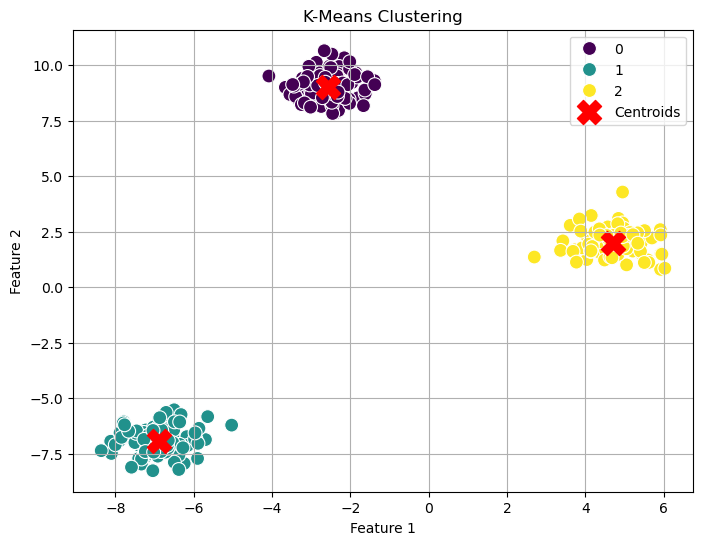

In [9]:
plt.figure(figsize=(8,6))


sns.scatterplot(
    x='Feature_1',
    y='Feature_2',
    hue='Cluster',
    data=df_kmeans,
    palette='viridis',
    s=100
)


plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c='red',
    marker='X',
    label='Centroids'
)


plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.legend()
plt.grid(True)

plt.show()

In [11]:
silhouette_avg = silhouette_score(
    X,
    clusters
)


print(
    "Silhouette Score:",
    round(silhouette_avg,3)
)

Silhouette Score: 0.908


In [13]:
X_pca, y_pca = make_blobs(
    n_samples=500,
    n_features=4,
    centers=4,
    cluster_std=1.0,
    random_state=25
)


df_pca = pd.DataFrame(
    X_pca,
    columns=[
        'Feature_1',
        'Feature_2',
        'Feature_3',
        'Feature_4'
    ]
)


df_pca['Cluster'] = y_pca


print(df_pca.head())

print("Dataset Shape:", df_pca.shape)

   Feature_1  Feature_2  Feature_3  Feature_4  Cluster
0  -0.638667   1.110057  -6.400722  -0.204990        3
1  -2.951556  -7.657445   3.844794   0.903589        1
2  -0.253177   2.125103  -7.869801   0.559678        3
3  -2.151209   3.401400  -5.734930   0.965230        3
4  -2.347519  -7.230467   3.478891  -0.443440        1
Dataset Shape: (500, 5)


In [15]:
scaler = StandardScaler()


X_pca_scaled = scaler.fit_transform(
    X_pca
)


print("Standardization Completed")

Standardization Completed


In [17]:
pca = PCA(
    n_components=2
)


principal_components = pca.fit_transform(
    X_pca_scaled
)


df_principal = pd.DataFrame(
    principal_components,
    columns=[
        'PC1',
        'PC2'
    ]
)


df_principal['Cluster'] = y_pca


explained_variance = pca.explained_variance_ratio_


print(df_principal.head())


print(
    "Explained Variance Ratio:",
    explained_variance
)


print(
    "Total Variance:",
    round(explained_variance.sum(),3)
)

        PC1       PC2  Cluster
0  0.455305  1.623917        3
1 -2.705622  0.375012        1
2  0.810234  1.966926        3
3  0.427139  2.149626        3
4 -2.407508  0.099250        1
Explained Variance Ratio: [0.57208431 0.33622342]
Total Variance: 0.908


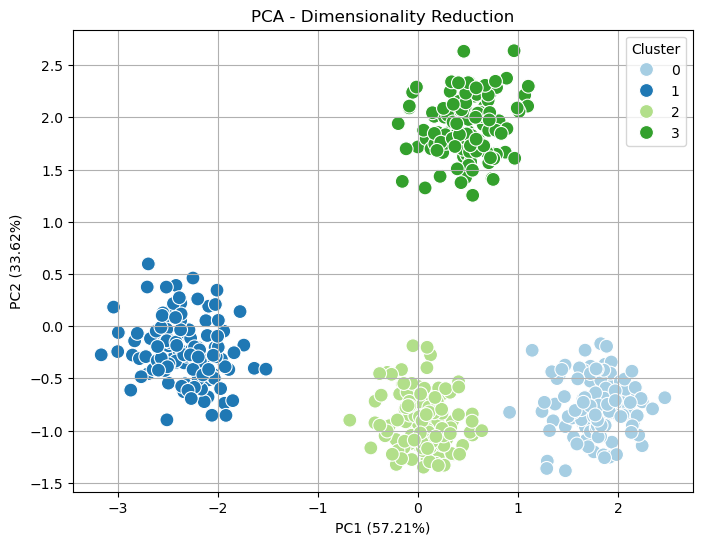

In [19]:
plt.figure(figsize=(8,6))


sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=df_principal,
    palette='Paired',
    s=100
)


plt.title(
    "PCA - Dimensionality Reduction"
)


plt.xlabel(
    f"PC1 ({explained_variance[0]*100:.2f}%)"
)

plt.ylabel(
    f"PC2 ({explained_variance[1]*100:.2f}%)"
)


plt.grid(True)

plt.show()

In [21]:
kmeans_pca = KMeans(
    n_clusters=4,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)


clusters_pca = kmeans_pca.fit_predict(
    principal_components
)


df_principal['KMeans_Cluster'] = clusters_pca


df_principal.head()

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,PC1,PC2,Cluster,KMeans_Cluster
0,0.455305,1.623917,3,0
1,-2.705622,0.375012,1,2
2,0.810234,1.966926,3,0
3,0.427139,2.149626,3,0
4,-2.407508,0.099250,1,2


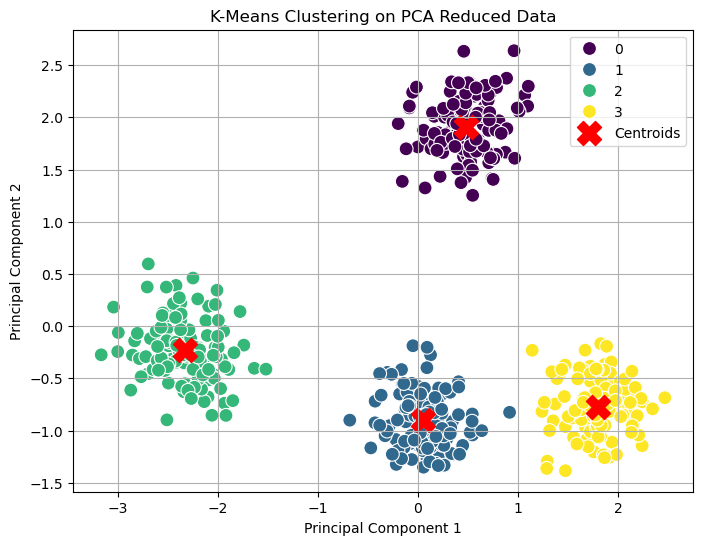

In [23]:
plt.figure(figsize=(8,6))


sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='KMeans_Cluster',
    data=df_principal,
    palette='viridis',
    s=100
)


plt.scatter(
    kmeans_pca.cluster_centers_[:,0],
    kmeans_pca.cluster_centers_[:,1],
    c='red',
    s=300,
    marker='X',
    label='Centroids'
)


plt.title(
    "K-Means Clustering on PCA Reduced Data"
)


plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend()

plt.grid(True)

plt.show()

In [25]:
silhouette_avg_pca = silhouette_score(
    principal_components,
    clusters_pca
)


print(
    "Silhouette Score after PCA:",
    round(silhouette_avg_pca,3)
)

Silhouette Score after PCA: 0.776
